In [1]:
import collections
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [2]:
results_path = "../results/"
models = ["BasicTransformer"]
configs = [f"d{d}_h{h}_L{l}" for d in [32, 64, 128, 256] for h in [4] for l in [1, 2, 4, 6]]

def get_data(root_dir, models, configs):
    data = []
    for model in models:
        for config in configs:
            search_path = os.path.join(root_dir, model, config)
            if not os.path.exists(search_path):
                continue

            for root, dirs, files in os.walk(search_path):
                for file in files:
                    if file.endswith(".json"):
                        with open(os.path.join(root, file), 'r') as f:
                            raw = json.load(f)
                            history = raw.get("history")
                            max_n = max([int(n) for n, acc in history.items() if acc >= 1.0])
                            flat_row = {
                                "architecture": raw["architecture"],
                                "d_model": raw["config"]["d_model"],
                                "n_heads": raw["config"]["n_heads"],
                                "n_layers": raw["config"]["n_layers"],
                                "parameters": raw["parameters"],
                                "payload_seed": raw["seeds"]["payload"],
                                "shuffle_seed": raw["seeds"]["shuffle"],
                                "init_seed": raw["seeds"]["init"],
                                "max_n": max_n,
                                "history": history
                            }
                            data.append(flat_row)

    return pd.DataFrame(data)

results = get_data(results_path, models, configs)
display(results.head())

,architecture,d_model,n_heads,n_layers,parameters,payload_seed,shuffle_seed,init_seed,max_n,history
0,BasicTransformer,32,4,1,21416,1000,2000,3000,512,"{'128': 1.0, '256': 1.0, '512': 1.0, '1024': 0..."
1,BasicTransformer,32,4,1,21416,1007,2007,3007,560,"{'128': 1.0, '256': 1.0, '512': 1.0, '1024': 0..."
2,BasicTransformer,32,4,1,21416,1009,2009,3009,560,"{'128': 1.0, '256': 1.0, '512': 1.0, '1024': 0..."
3,BasicTransformer,32,4,1,21416,1008,2008,3008,608,"{'128': 1.0, '256': 1.0, '512': 1.0, '1024': 0..."
4,BasicTransformer,32,4,1,21416,1006,2006,3006,544,"{'128': 1.0, '256': 1.0, '512': 1.0, '1024': 0..."


In [3]:
d_model = 32
n_layers = 6

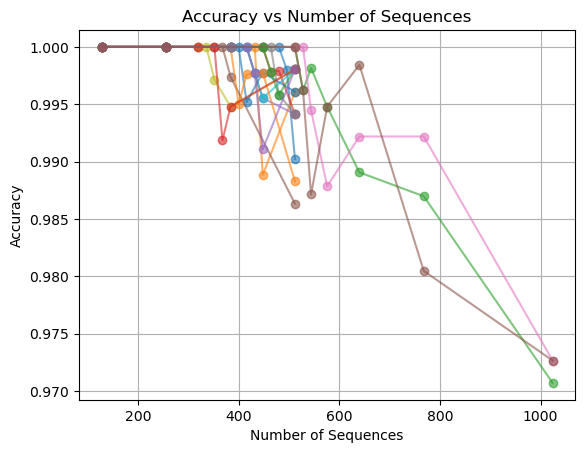

In [4]:
def plot_history(histories):
    for history in histories:
        data = sorted((int(k), v) for k, v in history.items())
        x = [item[0] for item in data]
        y = [item[1] for item in data]
        plt.plot(x, y, marker='o', linestyle='-', alpha=0.6)
    plt.title('Accuracy vs Number of Sequences')
    plt.xlabel('Number of Sequences')
    plt.ylabel('Accuracy')
    # plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.grid(True)
    plt.savefig("accuracy_vs_sequences.png")
    plt.show()
    plt.close()

plot_history(results[(results["d_model"] == d_model) & (results["n_layers"] == n_layers)]["history"])

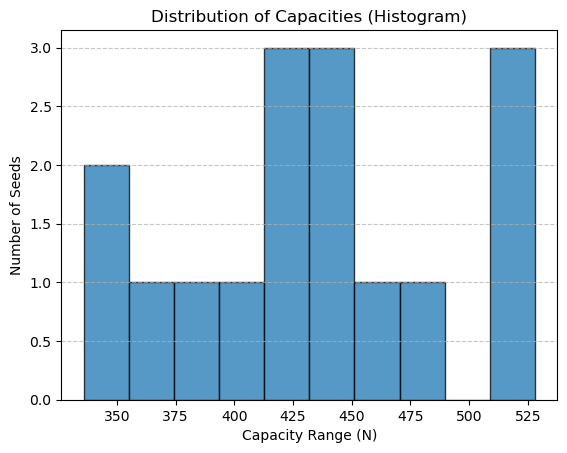

In [5]:
def plot_capacity_distribution_hist(capacities):
    clean_capacities = [c for c in capacities if pd.notnull(c)]

    plt.hist(clean_capacities, bins=10, edgecolor='black', alpha=0.75)
    plt.title('Distribution of Capacities (Histogram)')
    plt.xlabel('Capacity Range (N)')
    plt.ylabel('Number of Seeds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig("capacity_distribution_hist.png", dpi=300)
    plt.show()
    plt.close()

plot_capacity_distribution_hist(results[(results["d_model"] == d_model) & (results["n_layers"] == n_layers)]["max_n"])

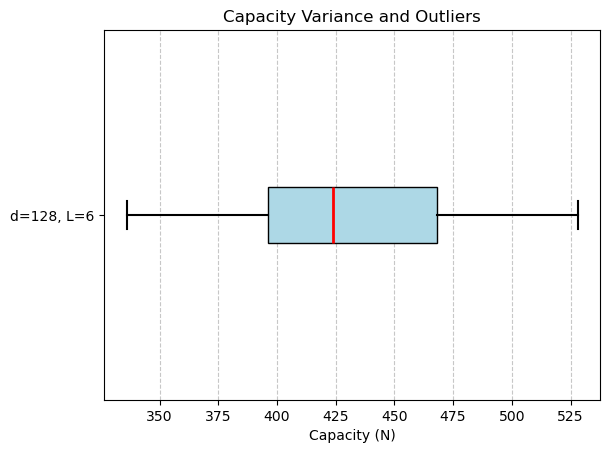

In [6]:
def plot_capacity_boxplot(capacities):
    clean_capacities = [c for c in capacities if pd.notnull(c)]

    plt.boxplot(clean_capacities, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='o', color='red', markersize=8, alpha=0.6))
    plt.title('Capacity Variance and Outliers')
    plt.xlabel('Capacity (N)')
    plt.yticks([1], ['d=128, L=6'])
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.savefig("capacity_boxplot.png", dpi=300)
    plt.show()
    plt.close()

plot_capacity_boxplot(results[(results["d_model"] == d_model) & (results["n_layers"] == n_layers)]["max_n"])

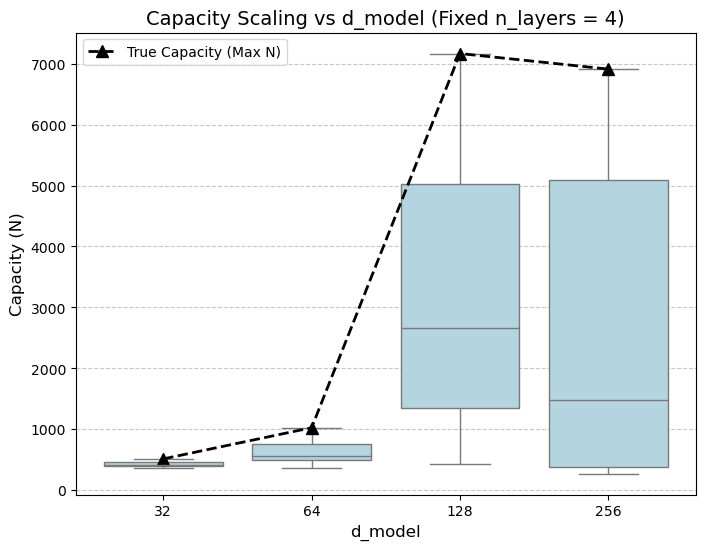

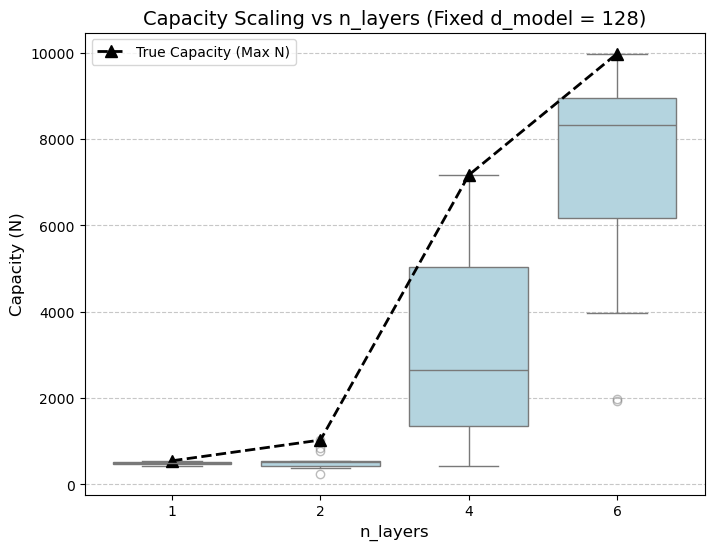

In [7]:
def plot_scaling_boxplot(df, fixed_param='n_layers', fixed_val=6, varying_param='d_model'):
    subset = df[df[fixed_param] == fixed_val].copy()

    # Sort the values so the x-axis goes from smallest to largest model
    subset = subset.sort_values(by=varying_param)

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x=varying_param,
        y='max_n',
        data=subset,
        color='lightblue',
        showfliers=True,
        flierprops=dict(marker='o', color='red', markersize=6, alpha=0.5)
    )

    max_capacities = subset.groupby(varying_param)['max_n'].max().values

    plt.plot(
        range(len(max_capacities)),
        max_capacities,
        color='black',
        marker='^',
        linestyle='--',
        linewidth=2,
        markersize=8,
        label='True Capacity (Max N)'
    )

    plt.title(f'Capacity Scaling vs {varying_param} (Fixed {fixed_param} = {fixed_val})', fontsize=14)
    plt.xlabel(varying_param, fontsize=12)
    plt.ylabel('Capacity (N)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    plt.savefig(f"scaling_{varying_param}_fixed_{fixed_param}{fixed_val}.png", dpi=300)
    plt.show()
    plt.close()

plot_scaling_boxplot(results, fixed_param='n_layers', fixed_val=4, varying_param='d_model')
plot_scaling_boxplot(results, fixed_param='d_model', fixed_val=128, varying_param='n_layers')

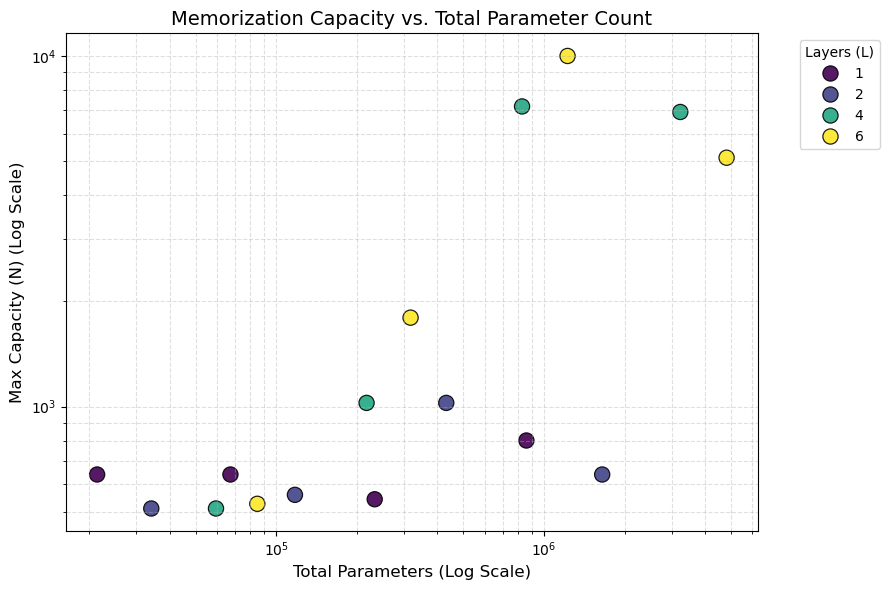

In [8]:
def plot_parameter_scaling(df):
    scaling_data = df.groupby(['parameters', 'n_layers', 'd_model'])['max_n'].max().reset_index()

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=scaling_data,
        x='parameters',
        y='max_n',
        hue='n_layers',
        palette='viridis', # A nice colormap that goes from dark to light
        s=120,             # Dot size
        edgecolor='black',
        alpha=0.9
    )

    plt.xscale('log')
    plt.yscale('log')

    plt.title('Memorization Capacity vs. Total Parameter Count', fontsize=14)
    plt.xlabel('Total Parameters (Log Scale)', fontsize=12)
    plt.ylabel('Max Capacity (N) (Log Scale)', fontsize=12)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend(title='Layers (L)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("parameter_scaling_loglog.png", dpi=300)
    plt.show()
    plt.close()

plot_parameter_scaling(results)

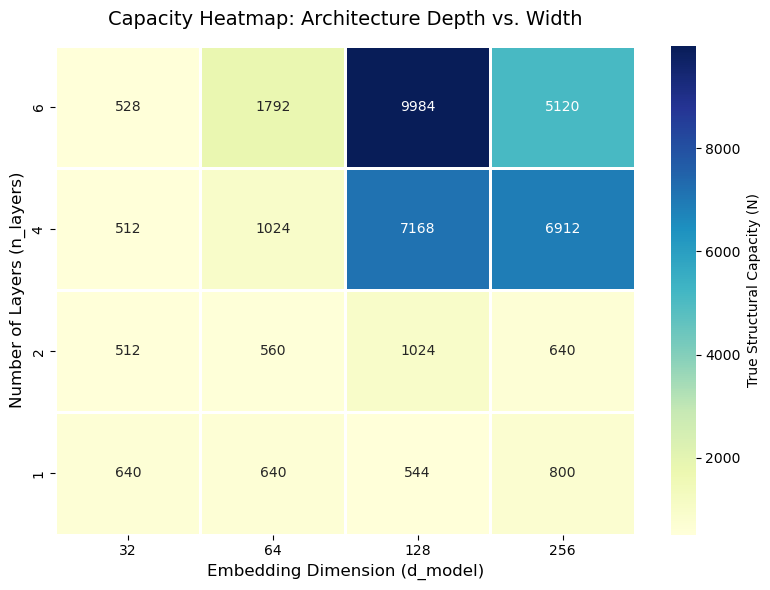

In [9]:
def plot_capacity_heatmap(df):
    heatmap_data = df.groupby(['n_layers', 'd_model'])['max_n'].max().reset_index()

    pivot_table = heatmap_data.pivot(index='n_layers', columns='d_model', values='max_n')

    pivot_table = pivot_table.sort_index(ascending=False)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': 'True Structural Capacity (N)'}
    )

    plt.title('Capacity Heatmap: Architecture Depth vs. Width', fontsize=14, pad=15)
    plt.xlabel('Embedding Dimension (d_model)', fontsize=12)
    plt.ylabel('Number of Layers (n_layers)', fontsize=12)
    plt.tight_layout()
    plt.savefig("capacity_heatmap.png", dpi=300)
    plt.show()
    plt.close()

# Pass your cleaned DataFrame directly in
plot_capacity_heatmap(results)